In [1]:
import os
import shutil
import random
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split

DATA_ROOT = "/home/anishma/Desktop/deep_fake_new/FF++"
REAL_SOURCE = os.path.join(DATA_ROOT, "original")
FAKE_SOURCE = os.path.join(DATA_ROOT, "Deepfakes")

OUTPUT_ROOT = "/home/anishma/Desktop/deep_fake_new/FFPP_split"

random.seed(42)

In [2]:
def get_videos(path):
    return sorted([f for f in os.listdir(path) if f.endswith(".mp4")])

real_videos = get_videos(REAL_SOURCE)
fake_videos = get_videos(FAKE_SOURCE)

real_videos = real_videos[:1000]
fake_videos = fake_videos[:1000]

print("Selected Real Videos:", len(real_videos))
print("Selected Fake Videos:", len(fake_videos))

Selected Real Videos: 1000
Selected Fake Videos: 1000


In [4]:
real_train, real_temp = train_test_split(real_videos, test_size=0.30, random_state=42)
real_val, real_test = train_test_split(real_temp, test_size=0.50, random_state=42)

fake_train, fake_temp = train_test_split(fake_videos, test_size=0.30, random_state=42)
fake_val, fake_test = train_test_split(fake_temp, test_size=0.50, random_state=42)

print("Train Real:", len(real_train))
print("Val Real:", len(real_val))
print("Test Real:", len(real_test))

print("Train Fake:", len(fake_train))
print("Val Fake:", len(fake_val))
print("Test Fake:", len(fake_test))

Train Real: 700
Val Real: 150
Test Real: 150
Train Fake: 700
Val Fake: 150
Test Fake: 150


In [7]:
splits = {
    "train": (real_train, fake_train),
    "val": (real_val, fake_val),
    "test": (real_test, fake_test)
}

for split in splits:
    os.makedirs(os.path.join(OUTPUT_ROOT, split, "real"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_ROOT, split, "fake"), exist_ok=True)

print("Folder structure created successfully")

Folder structure created successfully


In [8]:
def move_videos(video_list, source, dest):
    for video in video_list:
        shutil.copy(
            os.path.join(source, video),
            os.path.join(dest, video)
        )

for split, (real_list, fake_list) in splits.items():
    move_videos(real_list, REAL_SOURCE, os.path.join(OUTPUT_ROOT, split, "real"))
    move_videos(fake_list, FAKE_SOURCE, os.path.join(OUTPUT_ROOT, split, "fake"))

print("Videos moved into split folders")

Videos moved into split folders


In [9]:
FACE_OUTPUT = "/home/anishma/Desktop/deep_fake_new/FFPP_frames"

for split in ["train", "val", "test"]:
    for cls in ["real", "fake"]:
        os.makedirs(os.path.join(FACE_OUTPUT, split, cls), exist_ok=True)

In [14]:
import cv2
import numpy as np
import os

def extract_frames(video_path, save_dir, target_frames=200):

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        cap.release()
        return 0

    # Evenly sample across full video
    if total_frames <= target_frames:
        frame_indices = list(range(total_frames))
    else:
        frame_indices = np.linspace(
            0, total_frames - 1,
            target_frames,
            dtype=int
        )

    saved = 0
    video_name = os.path.splitext(os.path.basename(video_path))[0]

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()

        if not ret:
            continue

        frame = cv2.resize(frame, (224, 224))

        filename = f"{video_name}_{idx}.jpg"
        cv2.imwrite(os.path.join(save_dir, filename), frame)

        saved += 1

    cap.release()
    return saved

In [16]:
from tqdm import tqdm

VIDEO_ROOT = "/home/anishma/Desktop/deep_fake_new/FFPP_split"
FRAME_ROOT = "/home/anishma/Desktop/deep_fake_new/FFPP_frames"
total_frames_saved = 0

for split in ["train", "val", "test"]:
    for cls in ["real", "fake"]:

        video_folder = os.path.join(VIDEO_ROOT, split, cls)
        save_folder = os.path.join(FRAME_ROOT, split, cls)

        os.makedirs(save_folder, exist_ok=True)

        videos = [v for v in os.listdir(video_folder) if v.endswith(".mp4")]

        print(f"\nProcessing {split}/{cls} - {len(videos)} videos")

        for video in tqdm(videos):
            video_path = os.path.join(video_folder, video)
            frames = extract_frames(video_path, save_folder, target_frames=200)
            total_frames_saved += frames

print("\n==============================")
print("TOTAL FRAMES SAVED:", total_frames_saved)
print("==============================")


Processing train/real - 700 videos


100%|███████████████████████████████████████| 700/700 [3:55:13<00:00, 20.16s/it]



Processing train/fake - 700 videos


100%|███████████████████████████████████████| 700/700 [3:43:26<00:00, 19.15s/it]



Processing val/real - 150 videos


...


Processing test/real - 150 videos


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [49:56<00:00, 19.97s/it]



Processing test/fake - 150 videos


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [48:10<00:00, 19.27s/it]


TOTAL FRAMES SAVED: 400000


In [11]:
import torch

print("GPU Name:", torch.cuda.get_device_name(0))
print("Total VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))

GPU Name: Quadro RTX 6000
Total VRAM (GB): 25.19


In [19]:
import torch
import torch.nn as nn
import torch.cuda.amp as amp
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
import os

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Quadro RTX 6000


In [21]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],
                         [0.5,0.5,0.5])
])

In [23]:
DATA_ROOT = "/home/anishma/Desktop/deep_fake_new/FFPP_frames"

train_dataset = datasets.ImageFolder(
    os.path.join(DATA_ROOT, "train"),
    transform=transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(DATA_ROOT, "val"),
    transform=transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(DATA_ROOT, "test"),
    transform=transform
)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

print("Class mapping:", train_dataset.class_to_idx)

Train size: 280000
Val size: 60000
Test size: 60000
Class mapping: {'fake': 0, 'real': 1}


In [24]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    num_workers=8,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=8,
    pin_memory=True
)

In [25]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=768, num_heads=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim, num_heads,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, 2048),
            nn.ReLU(),
            nn.Linear(2048, embed_dim)
        )

    def forward(self, x):
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + attn_out

        x_norm = self.norm2(x)
        x = x + self.mlp(x_norm)
        return x

In [26]:
class HCiT(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = timm.create_model(
            "xception",
            pretrained=True,
            num_classes=0
        )

        self.projection = nn.Linear(2048, 768)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, 768))
        self.pos_embed = nn.Parameter(torch.zeros(1, 50, 768))

        self.transformer = nn.Sequential(
            *[TransformerBlock() for _ in range(4)]
        )

        self.norm = nn.LayerNorm(768)
        self.head = nn.Linear(768, 2)

    def forward(self, x):
        features = self.cnn.forward_features(x)
        B, C, H, W = features.shape

        features = features.view(B, C, -1)
        features = features.permute(0, 2, 1)

        tokens = self.projection(features)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat((cls_tokens, tokens), dim=1)

        tokens = tokens + self.pos_embed
        tokens = self.transformer(tokens)

        cls_out = tokens[:, 0]
        cls_out = self.norm(cls_out)

        return self.head(cls_out)

In [27]:
model = HCiT().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scaler = amp.GradScaler()

/home/anishma/anaconda3/envs/sri/lib/python3.9/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


In [1]:
import os
import cv2
import dlib
from tqdm import tqdm

In [2]:
detector = dlib.get_frontal_face_detector()

predictor = dlib.shape_predictor(
    "/home/anishma/Desktop/deep_fake_new/shape_predictor_68_face_landmarks.dat"
)

print("Dlib loaded successfully")

Dlib loaded successfully


In [3]:
FRAME_ROOT = "/home/anishma/Desktop/deep_fake_new/FFPP_frames"
CROP_ROOT  = "/home/anishma/Desktop/deep_fake_new/FFPP_faces"

splits = ["train", "val", "test"]
classes = ["real", "fake"]

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(CROP_ROOT, split, cls), exist_ok=True)

print("Crop folders created")

Crop folders created


In [4]:
def crop_face_from_frame(img_path, save_path):

    img = cv2.imread(img_path)
    if img is None:
        return False

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = detector(gray)

    if len(faces) == 0:
        return False

    # Use largest detected face
    face = max(faces, key=lambda rect: rect.width() * rect.height())

    x = max(0, face.left())
    y = max(0, face.top())
    w = face.width()
    h = face.height()

    crop = img[y:y+h, x:x+w]

    if crop.size == 0:
        return False

    crop = cv2.resize(crop, (224, 224))
    cv2.imwrite(save_path, crop)

    return True

In [5]:
total_saved = 0
total_failed = 0

for split in splits:
    for cls in classes:

        input_folder  = os.path.join(FRAME_ROOT, split, cls)
        output_folder = os.path.join(CROP_ROOT, split, cls)

        images = [f for f in os.listdir(input_folder) if f.endswith(".jpg")]

        print(f"\nProcessing {split}/{cls} - {len(images)} frames")

        for img_name in tqdm(images):

            img_path = os.path.join(input_folder, img_name)
            save_path = os.path.join(output_folder, img_name)

            success = crop_face_from_frame(img_path, save_path)

            if success:
                total_saved += 1
            else:
                total_failed += 1

print("\n==============================")
print("TOTAL CROPPED FACES:", total_saved)
print("TOTAL FAILED:", total_failed)
print("==============================")


Processing train/real - 140000 frames


100%|██████████████████████████████████| 140000/140000 [13:20<00:00, 174.80it/s]



Processing train/fake - 140000 frames


100%|██████████████████████████████████| 140000/140000 [13:18<00:00, 175.36it/s]



Processing val/real - 30000 frames


...


Processing test/real - 30000 frames


100%|████████████████████████████████████| 30000/30000 [03:08<00:00, 159.33it/s]



Processing test/fake - 30000 frames


100%|████████████████████████████████████| 30000/30000 [03:00<00:00, 166.32it/s]


TOTAL CROPPED FACES: 70470
TOTAL FAILED: 329530


In [6]:
def count_images(folder):
    return len([f for f in os.listdir(folder) if f.endswith(".jpg")])

print("\n📊 FINAL CROPPED DATASET SIZE")

total_real = 0
total_fake = 0

for split in splits:
    real_count = count_images(os.path.join(CROP_ROOT, split, "real"))
    fake_count = count_images(os.path.join(CROP_ROOT, split, "fake"))

    total_real += real_count
    total_fake += fake_count

    print(f"\n{split.upper()}")
    print("Real:", real_count)
    print("Fake:", fake_count)
    print("Total:", real_count + fake_count)

print("\nOVERALL")
print("Total Real:", total_real)
print("Total Fake:", total_fake)
print("Grand Total:", total_real + total_fake)


📊 FINAL CROPPED DATASET SIZE

TRAIN
Real: 26530
Fake: 25191
Total: 51721

VAL
Real: 5171
Fake: 4622
Total: 9793

TEST
Real: 4460
Fake: 4496
Total: 8956

OVERALL
Total Real: 36161
Total Fake: 34309
Grand Total: 70470


In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
from tqdm import tqdm
import os

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [43]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.1,0.1,0.1,0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [44]:
DATA_ROOT = "/home/anishma/Desktop/deep_fake_new/FFPP_faces"

train_dataset = datasets.ImageFolder(
    os.path.join(DATA_ROOT, "train"),
    transform=transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(DATA_ROOT, "val"),
    transform=transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(DATA_ROOT, "test"),
    transform=transform
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))
print("Class mapping:", train_dataset.class_to_idx)

Train: 51721
Val: 9793
Test: 8956
Class mapping: {'fake': 0, 'real': 1}


In [45]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

In [46]:
print(train_dataset.class_to_idx)
print(len(train_dataset))
print(len(val_dataset))

{'fake': 0, 'real': 1}
51721
9793


In [47]:
model = timm.create_model(
    'vit_base_patch16_224',
    pretrained=True,
    num_classes=2
)

model = model.to(device)

In [48]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [49]:
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F

EPOCHS = 20

for epoch in range(EPOCHS):

    # ================== TRAIN ==================
    model.train()
    running_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total


    # ================== VALIDATION ==================
    model.eval()
    val_correct = 0
    val_total = 0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            positive_probs = probs[:, 1]   # adjust if class index different
            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(positive_probs.cpu().numpy())

    val_acc = 100 * val_correct / val_total
    val_auc = roc_auc_score(all_labels, all_probs)


    # ================== PRINT ==================
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("Train Loss:", round(running_loss/len(train_loader), 4))
    print("Train Accuracy:", round(train_acc, 2), "%")
    print("Val Accuracy:", round(val_acc, 2), "%")
    print("Val AUC:", round(val_auc, 4))

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1617/1617 [09:57<00:00,  2.71it/s]



Epoch 1/20
Train Loss: 0.2519
Train Accuracy: 87.22 %
Val Accuracy: 90.37 %
Val AUC: 0.969


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1617/1617 [09:47<00:00,  2.75it/s]



Epoch 2/20
Train Loss: 0.0452
Train Accuracy: 98.43 %
Val Accuracy: 89.68 %
Val AUC: 0.9616


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1617/1617 [09:46<00:00,  2.76it/s]


...


Epoch 18/20
Train Loss: 0.0113
Train Accuracy: 99.61 %
Val Accuracy: 91.96 %
Val AUC: 0.9794


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1617/1617 [10:10<00:00,  2.65it/s]



Epoch 19/20
Train Loss: 0.0105
Train Accuracy: 99.64 %
Val Accuracy: 90.16 %
Val AUC: 0.9672


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1617/1617 [10:13<00:00,  2.64it/s]



Epoch 20/20
Train Loss: 0.0111
Train Accuracy: 99.6 %
Val Accuracy: 88.28 %
Val AUC: 0.9701


In [50]:
def evaluate(loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


val_acc = evaluate(val_loader)
print("Validation Accuracy:", val_acc)

Validation Accuracy: 88.14459307668743


In [51]:
test_acc = evaluate(test_loader)
print("Test Accuracy:", test_acc)

Test Accuracy: 83.00580616346583


In [56]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
import numpy as np
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Quadro RTX 6000


In [58]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [60]:
DATA_ROOT = "/home/anishma/Desktop/deep_fake_new/FFPP_faces"

train_dataset = datasets.ImageFolder(
    os.path.join(DATA_ROOT, "train"),
    transform=transform
)
val_dataset = datasets.ImageFolder(
    os.path.join(DATA_ROOT, "val"),
    transform=transform
)
test_dataset = datasets.ImageFolder(
    os.path.join(DATA_ROOT, "test"),
    transform=transform
)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))
print("Class mapping:", train_dataset.class_to_idx)

Train size: 51721
Val size: 9793
Test size: 8956
Class mapping: {'fake': 0, 'real': 1}


In [61]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=8,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=8,
    pin_memory=True
)

In [62]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim=768, num_heads=8, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim, num_heads,
            dropout=dropout,
            batch_first=True
        )
        
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x2 = self.norm1(x)
        attn_out, _ = self.attn(x2, x2, x2)
        x = x + attn_out

        x2 = self.norm2(x)
        x = x + self.mlp(x2)
        
        return x

In [63]:
class HCiT(nn.Module):
    def __init__(self, embed_dim=768, num_heads=8, depth=6):
        super().__init__()

        # Xception feature extractor
        self.cnn = timm.create_model(
            "xception", pretrained=True, num_classes=0
        )

        # Linear projection from CNN to embedding
        self.projection = nn.Linear(2048, embed_dim)

        # CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Positional embedding (49 spatial tokens + CLS)
        self.pos_embed = nn.Parameter(torch.zeros(1, 50, embed_dim))

        # Transformer encoder layers
        self.transformer = nn.Sequential(
            *[TransformerEncoderBlock(embed_dim, num_heads) for _ in range(depth)]
        )

        # Normalization + classifier
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, 2)

    def forward(self, x):
        # CNN feature maps
        features = self.cnn.forward_features(x)  # (B, 2048, 7, 7)

        B, C, H, W = features.shape
        
        # Flatten spatial
        features = features.view(B, C, -1)       # (B, 2048, 49)
        features = features.permute(0, 2, 1)     # (B, 49, 2048)

        # Linear projection
        tokens = self.projection(features)       # (B, 49, embed_dim)

        # Add CLS token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat((cls_tokens, tokens), dim=1)

        # Add position embedding
        tokens = tokens + self.pos_embed

        # Transformer
        tokens = self.transformer(tokens)

        # CLS output
        cls_out = tokens[:, 0]
        cls_out = self.norm(cls_out)

        # Final classifier
        out = self.head(cls_out)
        return out

In [64]:
model = HCiT().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

print("Model & optimizer ready!")

/home/anishma/anaconda3/envs/sri/lib/python3.9/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Model & optimizer ready!


In [65]:
from sklearn.metrics import roc_auc_score
import torch

EPOCHS = 20
PATIENCE = 5   # stop if no improvement for 5 epochs

best_val_auc = 0
epochs_no_improve = 0

for epoch in range(1, EPOCHS + 1):

    # ================== TRAIN ==================
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total


    # ================== VALIDATION ==================
    model.eval()
    val_correct = 0
    val_total = 0
    val_probs = []
    val_labels_list = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            val_probs.extend(probs.cpu().numpy())
            val_labels_list.extend(labels.cpu().numpy())

    val_acc = 100 * val_correct / val_total
    val_auc = roc_auc_score(val_labels_list, val_probs)


    # ================== PRINT ==================
    print(f"\nEpoch {epoch}/{EPOCHS}")
    print(f"Train Loss: {train_loss/len(train_loader):.4f}")
    print(f"Train Acc: {train_acc:.2f}%")
    print(f"Val Acc: {val_acc:.2f}%")
    print(f"Val AUC: {val_auc:.4f}")


    # ================== SAVE BEST ==================
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), "best_hcit_model.pth")
        print(" New Best Model Saved!")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")

    # ================== EARLY STOPPING ==================
    if epochs_no_improve >= PATIENCE:
        print(" Early stopping triggered!")
        break

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1617/1617 [06:29<00:00,  4.15it/s]



Epoch 1/20
Train Loss: 0.0597
Train Acc: 97.67%
Val Acc: 88.80%
Val AUC: 0.9693
 New Best Model Saved!


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1617/1617 [06:25<00:00,  4.19it/s]



Epoch 2/20
Train Loss: 0.0117
Train Acc: 99.66%
Val Acc: 91.32%
Val AUC: 0.9781
 New Best Model Saved!


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1617/1617 [06:27<00:00,  4.17it/s]


...


Epoch 6/20
Train Loss: 0.0037
Train Acc: 99.89%
Val Acc: 92.10%
Val AUC: 0.9814
No improvement for 3 epoch(s)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1617/1617 [06:23<00:00,  4.22it/s]



Epoch 7/20
Train Loss: 0.0035
Train Acc: 99.89%
Val Acc: 91.38%
Val AUC: 0.9706
No improvement for 4 epoch(s)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1617/1617 [06:19<00:00,  4.26it/s]



Epoch 8/20
Train Loss: 0.0044
Train Acc: 99.89%
Val Acc: 85.33%
Val AUC: 0.9689
No improvement for 5 epoch(s)
 Early stopping triggered!



Final Test Accuracy: 92.05002233139794
Final Test AUC: 0.9856800713738568

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.88      0.92      4496
           1       0.89      0.96      0.92      4460

    accuracy                           0.92      8956
   macro avg       0.92      0.92      0.92      8956
weighted avg       0.92      0.92      0.92      8956



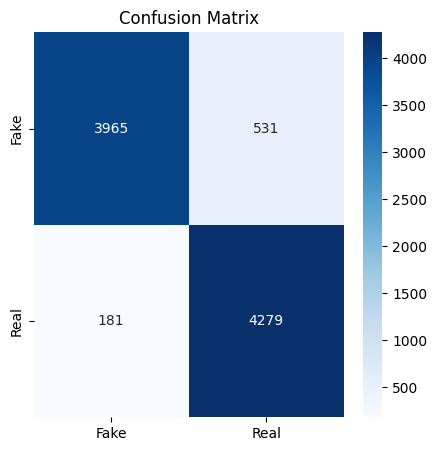

In [66]:
model.load_state_dict(torch.load("best_hcit_model.pth"))
model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        positive_probs = probs[:, 1]
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(positive_probs.cpu().numpy())

test_acc = 100 * (sum([p==l for p,l in zip(all_preds, all_labels)]) / len(all_labels))
test_auc = roc_auc_score(all_labels, all_probs)

print("\nFinal Test Accuracy:", test_acc)
print("Final Test AUC:", test_auc)

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake","Real"],
            yticklabels=["Fake","Real"])
plt.title("Confusion Matrix")
plt.show()

In [67]:
import torch
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = HCiT().to(device)
model.load_state_dict(torch.load("best_hcit_model.pth"))
model.eval()

print("HCiT model loaded successfully!")

/home/anishma/anaconda3/envs/sri/lib/python3.9/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


HCiT model loaded successfully!


In [68]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [69]:
import dlib

detector = dlib.get_frontal_face_detector()

In [71]:
import cv2
import numpy as np
import os

def predict_video(video_path, max_frames=200):

    print("="*70)
    print("Analyzing:", os.path.basename(video_path))
    print("="*70)

    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    if total_frames == 0:
        return "Invalid video"

    # Evenly sample frames
    frame_indices = np.linspace(
        0, total_frames-1, max_frames
    ).astype(int)

    real_probs = []
    fake_probs = []

    current_frame = 0
    processed = 0
    faces_detected = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if current_frame in frame_indices:

            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            faces = detector(gray)

            if len(faces) > 0:
                faces_detected += 1

            for face in faces:
                x, y, w, h = face.left(), face.top(), face.width(), face.height()
                crop = frame[y:y+h, x:x+w]

                if crop.size == 0:
                    continue

                crop = cv2.resize(crop, (224,224))
                img = transform(crop).unsqueeze(0).to(device)

                with torch.no_grad():
                    output = model(img)
                    probs = F.softmax(output, dim=1)

                    fake_prob = probs[0, 0].item()
                    real_prob = probs[0, 1].item()

                    fake_probs.append(fake_prob)
                    real_probs.append(real_prob)

            processed += 1

        current_frame += 1

    cap.release()

    if len(fake_probs) == 0:
        print("No face detected in video.")
        return

    avg_fake = np.mean(fake_probs)
    avg_real = np.mean(real_probs)

    if avg_fake > avg_real:
        label = "FAKE"
        confidence = avg_fake
    else:
        label = "REAL"
        confidence = avg_real

    print("\nResult")
    print("Frames analyzed:", processed)
    print("Faces detected:", faces_detected)
    print("Average REAL probability:", round(avg_real*100, 2), "%")
    print("Average FAKE probability:", round(avg_fake*100, 2), "%")
    print("\n🎯 FINAL PREDICTION:", label)
    print("Confidence:", round(confidence*100, 2), "%")

    return label, confidence

In [72]:
video_path = "/home/anishma/Desktop/deep_fake_new/FF++/Deepfakes/000_003.mp4"

predict_video(video_path)

Analyzing: 000_003.mp4

Result
Frames analyzed: 200
Faces detected: 200
Average REAL probability: 8.83 %
Average FAKE probability: 91.17 %

🎯 FINAL PREDICTION: FAKE
Confidence: 91.17 %


('FAKE', 0.9117088528349996)

In [11]:
import sys
print(sys.executable)

/home/anishma/anaconda3/envs/sri/bin/python


In [1]:
pip install open_clip_torch

Note: you may need to restart the kernel to use updated packages.


In [15]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

DATA_ROOT = "/home/anishma/Desktop/deep_fake_new/FFPP_faces"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

train_dataset = datasets.ImageFolder(
    os.path.join(DATA_ROOT, "train"),
    transform=transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(DATA_ROOT, "val"),
    transform=transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(DATA_ROOT, "test"),
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 1617
Val batches: 307
Test batches: 280


In [16]:
import torch
import torch.nn as nn
import timm
import open_clip

class CNN_CLIP(nn.Module):

    def __init__(self):
        super().__init__()

        # ===== CNN Backbone (same as paper) =====
        self.cnn = timm.create_model(
            "xception",
            pretrained=True,
            num_classes=0
        )

        # CNN output → 2048
        self.projection = nn.Linear(2048, 512)

        # ===== CLIP MODEL =====
        self.clip_model, _, _ = open_clip.create_model_and_transforms(
            'ViT-B-16',
            pretrained='openai'
        )

        # Freeze all CLIP first
        for param in self.clip_model.parameters():
            param.requires_grad = False

        # Unfreeze LAST 4 transformer blocks
        for block in self.clip_model.visual.transformer.resblocks[-4:]:
            for param in block.parameters():
                param.requires_grad = True

        # classifier
        self.fc = nn.Linear(512, 2)

    def forward(self, x):

        # ===== CNN feature =====
        feat = self.cnn.forward_features(x)     # B,2048,7,7
        feat = feat.mean(dim=[2,3])             # GAP → B,2048

        feat = self.projection(feat)            # B,512

        # ===== CLIP expects tokens internally =====
        clip_feat = self.clip_model.visual.forward(x)

        # fuse CNN + CLIP features
        fused = feat + clip_feat

        out = self.fc(fused)

        return out

In [17]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Quadro RTX 6000


In [25]:
model = CNN_CLIP().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW([
    {"params": model.cnn.parameters(), "lr": 1e-4},
    {"params": model.clip_model.visual.parameters(), "lr": 3e-5},
    {"params": model.fc.parameters(), "lr": 1e-4},
    {"params": model.projection.parameters(), "lr": 1e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

/home/anishma/anaconda3/envs/sri/lib/python3.9/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(
/home/anishma/anaconda3/envs/sri/lib/python3.9/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [26]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [27]:
from tqdm import tqdm

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import numpy as np

In [29]:
from sklearn.metrics import roc_auc_score

In [30]:
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [31]:
EPOCHS = 20
best_auc = 0

for epoch in range(EPOCHS):

    # ================= TRAIN =================
    model.train()

    train_loss = 0
    train_correct = 0
    total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        train_correct += (preds == labels).sum().item()

    train_acc = 100 * train_correct / total


    # ================= VALIDATION =================
    model.eval()

    val_correct = 0
    val_total = 0

    all_probs = []
    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)[:,1]

            _, preds = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_acc = 100 * val_correct / val_total
    val_auc = roc_auc_score(all_labels, all_probs)

    scheduler.step()

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("Train Loss:", train_loss/len(train_loader))
    print("Train Acc:", train_acc)
    print("Val Acc:", val_acc)
    print("Val AUC:", val_auc)

    # ===== save best =====
    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), "best_cnn_clip.pth")
        print("⭐ Best model saved")

100%|███████████████████████████████████████| 1617/1617 [10:21<00:00,  2.60it/s]



Epoch 1/20
Train Loss: 0.023063830207738185
Train Acc: 99.14154792057384
Val Acc: 93.79148371285612
Val AUC: 0.9872834771289238
⭐ Best model saved


100%|███████████████████████████████████████| 1617/1617 [10:22<00:00,  2.60it/s]



Epoch 2/20
Train Loss: 0.0033917029788328723
Train Acc: 99.89172676475707
Val Acc: 91.70836311651179
Val AUC: 0.9870581876542288


100%|███████████████████████████████████████| 1617/1617 [10:22<00:00,  2.60it/s]


...


Epoch 18/20
Train Loss: 2.8906739948755932e-06
Train Acc: 100.0
Val Acc: 97.42673338098642
Val AUC: 0.9986166318317687


100%|███████████████████████████████████████| 1617/1617 [10:22<00:00,  2.60it/s]



Epoch 19/20
Train Loss: 4.450441695958924e-06
Train Acc: 100.0
Val Acc: 97.97814765648933
Val AUC: 0.9984600651655402


100%|███████████████████████████████████████| 1617/1617 [10:22<00:00,  2.60it/s]



Epoch 20/20
Train Loss: 1.4526270034100729e-06
Train Acc: 100.0
Val Acc: 98.10068416215664
Val AUC: 0.9986846015135671


In [32]:
# ===== Load best model =====
model.load_state_dict(torch.load("best_cnn_clip.pth"))
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        positive_probs = probs[:,1]

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(positive_probs.cpu().numpy())

test_acc = 100 * (np.array(all_preds) == np.array(all_labels)).mean()
test_auc = roc_auc_score(all_labels, all_probs)

print("\n FINAL TEST ACC:", test_acc)
print(" FINAL TEST AUC:", test_auc)

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds))


 FINAL TEST ACC: 97.59937472085753
 FINAL TEST AUC: 0.9968365004069386

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      4496
           1       0.96      0.99      0.98      4460

    accuracy                           0.98      8956
   macro avg       0.98      0.98      0.98      8956
weighted avg       0.98      0.98      0.98      8956



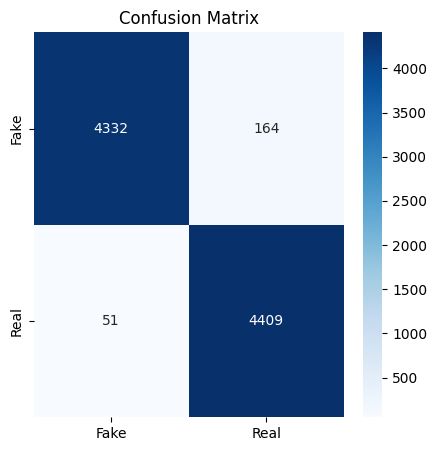

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake","Real"],
            yticklabels=["Fake","Real"])
plt.title("Confusion Matrix")
plt.show()

In [2]:
import torch
import torch.nn as nn
import timm
import open_clip

class CNN_CLIP(nn.Module):

    def __init__(self):
        super().__init__()

        # CNN backbone
        self.cnn = timm.create_model(
            "legacy_xception",
            pretrained=True,
            num_classes=0
        )

        self.projection = nn.Linear(2048, 512)

        # CLIP
        self.clip_model, _, _ = open_clip.create_model_and_transforms(
            "ViT-B-16",
            pretrained="openai"
        )

        # freeze all CLIP
        for p in self.clip_model.parameters():
            p.requires_grad = False

        # unfreeze last 4 blocks
        for block in self.clip_model.visual.transformer.resblocks[-4:]:
            for p in block.parameters():
                p.requires_grad = True

        self.fc = nn.Linear(512, 2)

    def forward(self, x):

        # CNN feature
        feat = self.cnn.forward_features(x)
        feat = feat.mean(dim=[2,3])
        feat = self.projection(feat)

        # CLIP feature
        clip_feat = self.clip_model.visual(x)

        fused = feat + clip_feat

        return self.fc(fused)

In [3]:
import torch
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_CLIP().to(device)
model.load_state_dict(torch.load("best_cnn_clip.pth"))
model.eval()

print("Model loaded successfully")

/home/anishma/anaconda3/envs/sri/lib/python3.9/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Model loaded successfully


In [4]:
import dlib

detector = dlib.get_frontal_face_detector()

In [5]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [6]:
import cv2
import numpy as np
import os

def predict_video(video_path, max_frames=200):

    print("="*60)
    print("Analyzing:", os.path.basename(video_path))
    print("="*60)

    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        print("Invalid video")
        return

    frame_indices = np.linspace(
        0, total_frames-1,
        max_frames
    ).astype(int)

    fake_probs = []
    real_probs = []

    current = 0
    processed = 0

    while True:

        ret, frame = cap.read()
        if not ret:
            break

        if current in frame_indices:

            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            faces = detector(gray)

            for face in faces:

                x = max(0, face.left())
                y = max(0, face.top())
                w = face.width()
                h = face.height()

                crop = frame[y:y+h, x:x+w]

                if crop.size == 0:
                    continue

                crop = cv2.resize(crop, (224,224))

                img = transform(crop).unsqueeze(0).to(device)

                with torch.no_grad():
                    out = model(img)
                    prob = F.softmax(out, dim=1)

                    fake_probs.append(prob[0,0].item())
                    real_probs.append(prob[0,1].item())

            processed += 1

        current += 1

    cap.release()

    if len(fake_probs) == 0:
        print("No face detected")
        return

    avg_fake = np.mean(fake_probs)
    avg_real = np.mean(real_probs)

    if avg_fake > avg_real:
        label = "FAKE"
        conf = avg_fake
    else:
        label = "REAL"
        conf = avg_real

    print("Frames analyzed:", processed)
    print("Avg Fake prob:", round(avg_fake*100,2), "%")
    print("Avg Real prob:", round(avg_real*100,2), "%")

    print("\n🎯 FINAL PREDICTION:", label)
    print("Confidence:", round(conf*100,2), "%")

    return label, conf

In [7]:
video_path = "/home/anishma/Desktop/deep_fake_new/FF++/Deepfakes/000_003.mp4"

predict_video(video_path)

Analyzing: 000_003.mp4
Frames analyzed: 200
Avg Fake prob: 100.0 %
Avg Real prob: 0.0 %

🎯 FINAL PREDICTION: FAKE
Confidence: 100.0 %


('FAKE', 0.9999916964769363)

In [8]:
folder = "/home/anishma/Desktop/deep_fake_new/FF++/original"

for v in os.listdir(folder)[:10]:
    if v.endswith(".mp4"):
        predict_video(os.path.join(folder, v))
        print()

Analyzing: 213.mp4
Frames analyzed: 200
Avg Fake prob: 0.0 %
Avg Real prob: 100.0 %

🎯 FINAL PREDICTION: REAL
Confidence: 100.0 %

Analyzing: 541.mp4
Frames analyzed: 200
Avg Fake prob: 7.78 %
Avg Real prob: 92.22 %

🎯 FINAL PREDICTION: REAL
Confidence: 92.22 %

Analyzing: 712.mp4
Frames analyzed: 200
Avg Fake prob: 0.0 %
Avg Real prob: 100.0 %

🎯 FINAL PREDICTION: REAL
Confidence: 100.0 %

Analyzing: 867.mp4
Frames analyzed: 200
Avg Fake prob: 0.46 %
Avg Real prob: 99.54 %

🎯 FINAL PREDICTION: REAL
Confidence: 99.54 %

Analyzing: 203.mp4
Frames analyzed: 200
Avg Fake prob: 0.17 %
Avg Real prob: 99.83 %

🎯 FINAL PREDICTION: REAL
Confidence: 99.83 %

Analyzing: 023.mp4
Frames analyzed: 200
Avg Fake prob: 65.78 %
Avg Real prob: 34.22 %

🎯 FINAL PREDICTION: FAKE
Confidence: 65.78 %

Analyzing: 987.mp4
Frames analyzed: 200
Avg Fake prob: 0.01 %
Avg Real prob: 99.99 %

🎯 FINAL PREDICTION: REAL
Confidence: 99.99 %

Analyzing: 205.mp4
Frames analyzed: 200
Avg Fake prob: 1.4 %
Avg Real prob: 9